# softmax heatmap plot (Julia)

- `OUTDIR` 環境変数で結果ディレクトリを指定
- 指定がない場合は `results/latest_softmax_heatmap` を参照

[10, 16, 27, 44, 72, 118, 193, 316, 518, 848, 1389, 2276, 3728, 6105, 10000]
[10, 14, 19, 27, 37, 52, 72, 100, 139, 193, 268, 373, 518, 720, 1000]


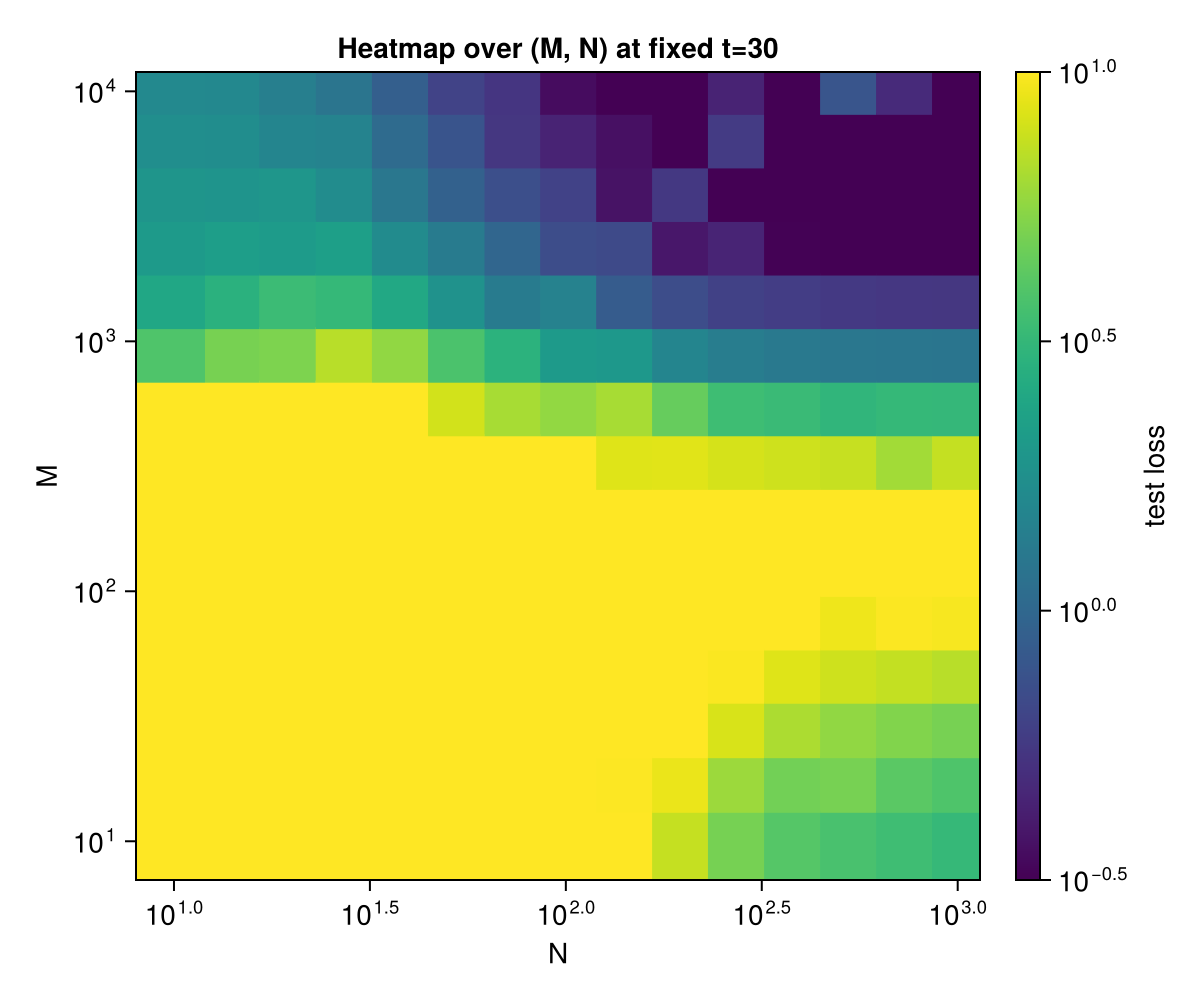

CairoMakie.Screen{IMAGE}


In [5]:
using CairoMakie
using DelimitedFiles

outdir = "/home/takanami/cot_asymptotics/softmax_heatmap/results/softmax_heatmap_20260410_195447"
#outdir = "/home/takanami/cot_asymptotics/softmax_heatmap/results/softmax_heatmap_20260411_003316"


function read_vector_int(path::String)
    raw = readdlm(path, ',', Float64)
    return Int.(round.(vec(raw)))
end

function read_config(path::String)
    cfg = Dict{String,String}()
    for line in eachline(path)
        s = strip(line)
        isempty(s) && continue
        if occursin("=", s)
            k, v = split(s, "=", limit=2)
            cfg[strip(k)] = strip(v)
        end
    end
    return cfg
end

function main(outdir=outdir)
    base_dir = @__DIR__
    figdir = joinpath(outdir, "figures")
    mkpath(figdir)

    cfg = read_config(joinpath(outdir, "config.txt"))
    M_list = read_vector_int(joinpath(outdir, "M_list.csv"))
    println(M_list)
    N_list = read_vector_int(joinpath(outdir, "N_list.csv"))
    println(N_list)
    T_list = read_vector_int(joinpath(outdir, "EVAL_T_list.csv"))
    T_heat = 30
    @assert T_heat in T_list "T_heat=$(T_heat) is not in EVAL_T_list.csv"

    curves_long = readdlm(joinpath(outdir, "curves_long.csv"), ',', Float64)
    # columns: m, n, t, error

    heat_path = joinpath(outdir, "heat_t$(T_heat).csv")
    if isfile(heat_path)
        heat = readdlm(heat_path, ',', Float64)
    else
        # heat ファイルが無ければ curves_long から t=T_heat の行を抽出して再構成
        heat = fill(NaN, length(M_list), length(N_list))
        for i in 1:size(curves_long, 1)
            m = Int(round(curves_long[i, 1]))
            n = Int(round(curves_long[i, 2]))
            t = Int(round(curves_long[i, 3]))
            err = curves_long[i, 4]
            if t == T_heat
                mi = findfirst(==(m), M_list)
                ni = findfirst(==(n), N_list)
                if mi !== nothing && ni !== nothing
                    heat[mi, ni] = err
                end
            end
        end
    end
    M_labels_plot = reverse(M_list)

    # ---- Figure 1: Heatmap at fixed t ----
    fig1 = Figure(size = (600, 500))
    ax1 = Axis(
        fig1[1, 1],
        xlabel = "N",
        ylabel = "M",
        title = "Heatmap over (M, N) at fixed t=$(T_heat)",
        xscale = log10,
        yscale = log10,
    )
    hm = heatmap!(ax1, N_list, M_list, 
        heat, colormap = :viridis, colorscale = log10, colorrange = (10^(-0.5), 10^1))
    Colorbar(fig1[1, 2], hm, label = "test loss")
    display(fig1)
end

main(outdir)